In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: []


In [2]:
# Paths & Hyperparameters
TRAINING_PATH   = 'D:\FINAL YEAR_PROJECT\Disease_Classification\Plants_dataSet\Pepper\Train'
VALIDATION_PATH = 'D:\FINAL YEAR_PROJECT\Disease_Classification\Plants_dataSet\Pepper\Validation'

BATCH_SIZE   = 32
IMG_SIZE     = (224, 224)
EPOCHS_HEAD  = 15   # phase 1: train new head only
EPOCHS_FINE  = 20   # phase 2: fine-tune top layers
UNFREEZE_N   = 50   # how many base layers to unfreeze from the end
LR_HEAD      = 1e-3
LR_FINE      = 1e-5

In [3]:
## 2. Data Augmentation (KEY accuracy booster)
# Applied on-the-fly during training only
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
], name='augmentation')

In [4]:
## 3. Load & Build Pipeline
training_set = tf.keras.utils.image_dataset_from_directory(
    TRAINING_PATH, label_mode='categorical',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
validation_set = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_PATH, label_mode='categorical',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = training_set.class_names
NUM_CLASSES = len(class_names)
print(f'Classes ({NUM_CLASSES}):', class_names)

# Save for web app
#with open('class_names.json', 'w') as f:
#    json.dump(class_names, f)
#print('class_names.json saved')

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    training_set
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE)
)

val_ds = (
    validation_set
    .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE)
)

Found 1980 files belonging to 2 classes.
Found 495 files belonging to 2 classes.
Classes (2): ['Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy']


In [5]:
## 4. Build Model (improved head with BatchNorm)
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,625,218 (10.01 MB)

 Trainable params: 364,162 (1.39 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [6]:
## 5. Phase 1 — Train head only
model.compile(
    optimizer=Adam(LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_head = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ModelCheckpoint('best_model_head.keras', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS_HEAD, callbacks=callbacks_head)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.8899 - loss: 0.2939 - top3_acc: 1.0000 - val_accuracy: 0.8808 - val_loss: 0.3093 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9697 - loss: 0.0855 - top3_acc: 1.0000 - val_accuracy: 0.9455 - val_loss: 0.1544 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9828 - loss: 0.0507 - top3_acc: 1.0000 - val_accuracy: 0.9515 - val_loss: 0.1312 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9919 - loss: 0.0270 - top3_acc: 1.0000 - val_accuracy: 0.9636 - val_loss: 0.0830 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 55s 894ms/step - accuracy: 0.9939 - loss: 0.0201 - top3_acc: 1.0000 - val_accuracy: 0.9697 - val_loss: 0.0824 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━

In [8]:
## 6. Phase 2 — Fine-tune top base layers
base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_N]:
    layer.trainable = False

print(f'Fine-tuning {sum(1 for l in base_model.layers if l.trainable)} base layers')

model.compile(
    optimizer=Adam(LR_FINE),  # must be very low!
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_fine = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ModelCheckpoint('best_model_final.keras', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.3, patience=4, min_lr=1e-8, verbose=1)
]

history_fine = model.fit(train_ds, validation_data=val_ds,
                         epochs=EPOCHS_FINE, callbacks=callbacks_fine)

Fine-tuning 50 base layers
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9359 - loss: 0.2129 - top3_acc: 1.0000 - val_accuracy: 0.9333 - val_loss: 0.2566 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9828 - loss: 0.0479 - top3_acc: 1.0000 - val_accuracy: 0.9212 - val_loss: 0.3431 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9889 - loss: 0.0317 - top3_acc: 1.0000 - val_accuracy: 0.9394 - val_loss: 0.2939 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9955 - loss: 0.0138 - top3_acc: 1.0000 - val_accuracy: 0.9394 - val_loss: 0.2637 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9979 - loss: 0.0088 - top3_acc: 1.0000
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
62/62 ━━━

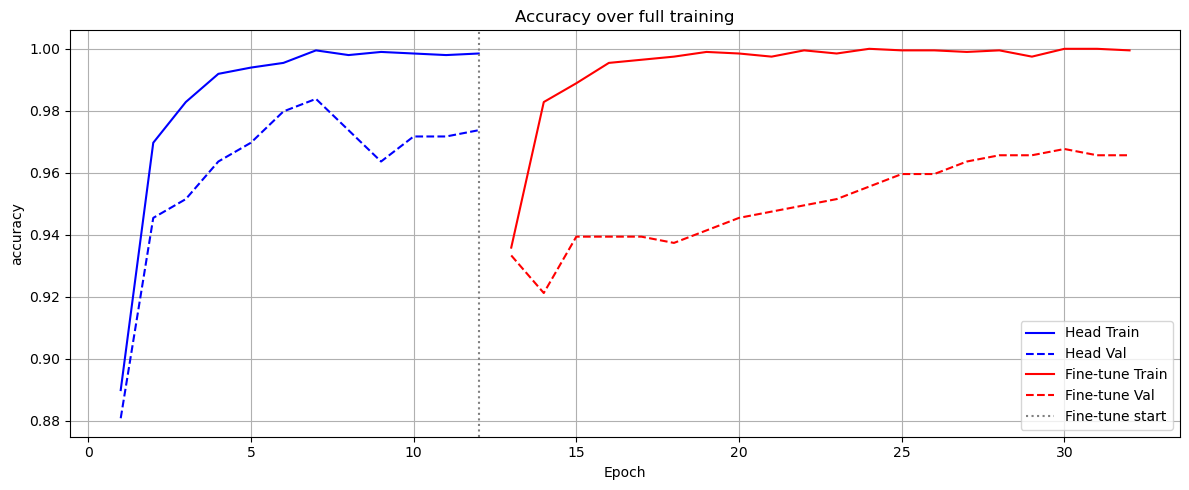

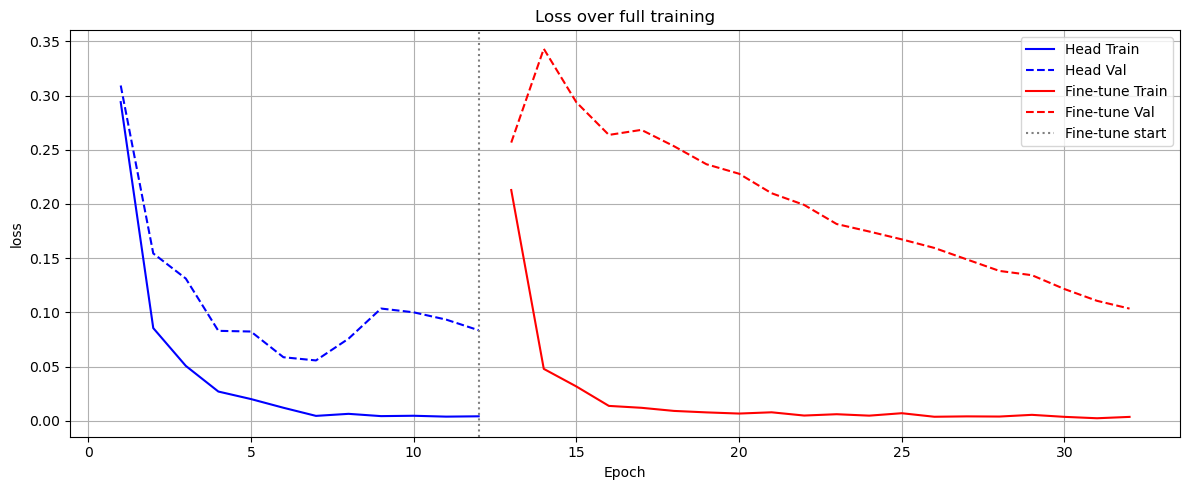

In [9]:
def plot_combined(h1, h2, metric='accuracy'):
    v1, val1 = h1.history[metric], h1.history[f'val_{metric}']
    v2, val2 = h2.history[metric], h2.history[f'val_{metric}']
    e1 = range(1, len(v1)+1)
    e2 = range(len(v1)+1, len(v1)+len(v2)+1)
    plt.figure(figsize=(12,5))
    plt.plot(list(e1), v1, 'b-',  label='Head Train')
    plt.plot(list(e1), val1, 'b--', label='Head Val')
    plt.plot(list(e2), v2, 'r-',  label='Fine-tune Train')
    plt.plot(list(e2), val2, 'r--', label='Fine-tune Val')
    plt.axvline(x=len(v1), color='gray', linestyle=':', label='Fine-tune start')
    plt.title(f'{metric.capitalize()} over full training')
    plt.xlabel('Epoch'); plt.ylabel(metric); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.savefig(f'training_{metric}.png', dpi=150); plt.show()

plot_combined(history, history_fine, 'accuracy')
plot_combined(history, history_fine, 'loss')

In [10]:
best = tf.keras.models.load_model('best_model_final.keras')
best.save('Pepper_disease.keras')
print('Saved: Pepper_disease.keras')

loss, acc, top3 = best.evaluate(val_ds)
print(f'\nVal Accuracy  : {acc*100:.2f}%')
print(f'Top-3 Accuracy: {top3*100:.2f}%')

Saved: Pepper_disease.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 668ms/step - accuracy: 0.9677 - loss: 0.1215 - top3_acc: 1.0000

Val Accuracy  : 96.77%
Top-3 Accuracy: 100.00%
